# 4. 前馈网络（FFN）—— 手搓 NumPy vs PyTorch（含 SwiGLU 变种）

本 notebook 手搓 Transformer 的位置级 MLP（逐 token 前馈网络），对比 ReLU/GELU/SiLU 激活，
并实现现代 LLM 用的 **SwiGLU** 门控变种（MiniMind/LLaMA 的 FeedForward 就是它）。

> 前置：第 1-2 讲（注意力）。FFN 是每个 Transformer 层的第二个子层，负责"记忆/转换"每个 token 的表示。


## 公式回顾

原始 Transformer（ReLU）：

$$FFN(x)=\max(0,\ xW_1+b_1)W_2+b_2$$

**GELU**（高斯误差线性单元，tanh 近似）：

$$GELU(x)\approx 0.5x\left(1+\tanh\left(\sqrt{2/\pi}\,(x+0.044715x^3)\right)\right)$$

**SwiGLU**（LLaMA/MiniMind 用，门控线性单元 + Swish）：

$$FFN_{SwiGLU}(x)=W_{down}\,\big(SiLU(W_{gate}\,x)\odot W_{up}\,x\big),\qquad SiLU(x)=x\cdot\sigma(x)=x\cdot\frac{1}{1+e^{-x}}$$

SwiGLU 用 3 个线性层（gate/up/down），其中 gate 学一个"门控"乘在 up 的输出上——比 ReLU 的硬截断更平滑，
给网络更强的非线性表达能力（参数量略增：$2d_{ff}\to 3d_{ff}$ 的中间层）。


## 导入


In [3]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import math

np.random.seed(0)
torch.manual_seed(0)
print('imports ready')

imports ready


## 手搓实现（纯 NumPy，含手搓反向传播）

- `linear_forward/backward`：线性层 $y=xW+b$，$dx=dout\,W^T$，$dW=x^T dout$（对 B,T 维求和），$db=\sum dout$
- `relu_forward/backward`：$y=\max(x,0)$，$dx=dout\cdot[x>0]$
- `gelu_forward/backward`：tanh 近似；导数为 $0.5\tanh(a)+0.5x(1-\tanh^2(a))\cdot\sqrt{2/\pi}(1+3\cdot0.044715x^2)$，$a=\sqrt{2/\pi}(x+0.044715x^3)$
- `ffn_forward/backward`：$x\to$ 线性1 $\to$ 激活 $\to$ 线性2 $\to$ out，用 cache 链式反传


In [5]:
def linear_forward(x, W, b):
    """线性层 forward：y = x @ W + b。
    x: [*, in]；W: [in, out]（行=输入、列=输出，与 torch Linear 的 [out,in] 相反，赋值时转置）；b: [out]"""
    return x @ W + b

def linear_backward(dout, x, W):
    """线性层 backward：dout: [*, out]，x: [*, in]。
    返回 dx = dout @ W.T（[*, in]）、dW = x^T @ dout 对前置维求和（[in, out]）、db = sum(dout)（[out]）"""
    dx = dout @ W.T
    dW = (x.reshape(-1, x.shape[-1]).T @ dout.reshape(-1, dout.shape[-1]))
    db = dout.reshape(-1, dout.shape[-1]).sum(axis=0)
    return dx, dW, db

def relu_forward(x):
    """ReLU forward：max(x, 0)。"""
    return np.maximum(x, 0.0), (x > 0)

def relu_backward(dout, mask):
    """ReLU backward：梯度只在 x>0 处通过（mask 是 x>0 的布尔掩码）。"""
    return dout * mask

def gelu_forward(x):
    """GELU forward（tanh 近似，与 torch F.gelu(approximate='tanh') 一致）。"""
    a = math.sqrt(2.0 / math.pi) * (x + 0.044715 * x ** 3)   # 内部参数 a
    return 0.5 * x * (1.0 + np.tanh(a)), a

def gelu_backward(dout, x, a):
    """GELU backward（tanh 近似的解析导数）。
    g(x)=0.5x(1+tanh(a))，a=√(2/π)(x+0.044715x³)：
    g'(x)=0.5(1+tanh(a)) + 0.5x(1−tanh²(a))·√(2/π)(1+3·0.044715x²)"""
    t = np.tanh(a)
    dgelu = 0.5 * (1 + t) + 0.5 * x * (1 - t ** 2) * math.sqrt(2.0 / math.pi) * (1 + 3 * 0.044715 * x ** 2)
    return dout * dgelu

def ffn_forward(x, W1, b1, W2, b2, act='gelu'):
    """两层 FFN forward：x -> Linear1 -> 激活 -> Linear2。
    返回 (out, cache)：cache 保存中间量供 backward 复用。"""
    h_pre = linear_forward(x, W1, b1)              # 线性层1：升维 [*, d_ff]
    if act == 'relu':
        h, mask = relu_forward(h_pre)             # ReLU 激活
        cache = (x, W1, b1, W2, b2, h_pre, h, mask, None)
    else:  # gelu
        h, a = gelu_forward(h_pre)                # GELU 激活
        cache = (x, W1, b1, W2, b2, h_pre, h, None, a)
    out = linear_forward(h, W2, b2)               # 线性层2：降维回 d_model
    return out, (cache, h)

def ffn_backward(dout, cache_info):
    """FFN backward（链式反传）：dout -> 线性2 -> 激活 -> 线性1。"""
    (cache, h) = cache_info
    x, W1, b1, W2, b2, h_pre, h_act, mask, a = cache
    dh, dW2, db2 = linear_backward(dout, h_act, W2)     # 线性层2 反传
    if mask is not None:                                 # ReLU 分支
        d_pre = relu_backward(dh, mask)
    else:                                                # GELU 分支
        d_pre = gelu_backward(dh, h_pre, a)
    dx, dW1, db1 = linear_backward(d_pre, x, W1)         # 线性层1 反传
    return dx, dW1, db1, dW2, db2


## PyTorch 参考

用 `nn.Linear` + 激活函数组装同样的两层 FFN。**对齐要点**：
- torch `nn.Linear(in, out)` 的权重是 `[out, in]`，手搓是 `[in, out]` → 赋值时转置
- GELU 用 `nn.GELU(approximate='tanh')` 显式选 tanh 近似（与手搓一致；默认 erf 会差 ~1e-3）


In [7]:
def make_torch_ffn(d_in, d_ff, W1, b1, W2, b2, act='gelu'):
    """用与手搓相同的权重构造 torch 两层 FFN（ReLU 或 GELU-tanh）。"""
    lin1 = nn.Linear(d_in, d_ff, bias=True, dtype=torch.float64)
    lin2 = nn.Linear(d_ff, d_in, bias=True, dtype=torch.float64)
    lin1.weight.data = torch.tensor(W1.T)   # [d_ff, d_in] = W1^T
    lin1.bias.data = torch.tensor(b1)
    lin2.weight.data = torch.tensor(W2.T)   # [d_in, d_ff] = W2^T
    lin2.bias.data = torch.tensor(b2)
    act_m = nn.ReLU() if act == 'relu' else nn.GELU(approximate='tanh')
    return nn.Sequential(lin1, act_m, lin2)


## 数值对比验证

对比 forward + 全部梯度（dx/dW1/db1/dW2/db2），另做一次有限差分自检。


In [9]:
B, T, d_model, d_ff = 2, 4, 8, 16
x_np = np.random.randn(B, T, d_model)
W1 = np.random.randn(d_model, d_ff) * 0.1
b1 = np.random.randn(d_ff) * 0.1
W2 = np.random.randn(d_ff, d_model) * 0.1
b2 = np.random.randn(d_model) * 0.1
dout = np.random.randn(B, T, d_model)

for act in ['relu', 'gelu']:
    # ---- forward 对比 ----
    out_np, info = ffn_forward(x_np, W1, b1, W2, b2, act=act)
    ffn_t = make_torch_ffn(d_model, d_ff, W1, b1, W2, b2, act=act)
    x_t = torch.tensor(x_np, dtype=torch.float64, requires_grad=True)
    out_t = ffn_t(x_t)
    e_f = float((out_t.detach().numpy() - out_np).max())
    assert np.allclose(out_np, out_t.detach().numpy(), rtol=1e-4, atol=1e-6)
    # ---- backward 对比 ----
    dx, dW1n, db1n, dW2n, db2n = ffn_backward(dout, info)
    out_t.backward(torch.tensor(dout, dtype=torch.float64))
    errs = [float(np.abs(dx - x_t.grad.numpy()).max()),
            float(np.abs(dW1n - ffn_t[0].weight.grad.numpy().T).max()),
            float(np.abs(db1n - ffn_t[0].bias.grad.numpy()).max()),
            float(np.abs(dW2n - ffn_t[2].weight.grad.numpy().T).max()),
            float(np.abs(db2n - ffn_t[2].bias.grad.numpy()).max())]
    assert all(e < 1e-4 for e in errs), (act, errs)
    print(f'{act:4s}: forward {e_f:.3e} | dx {errs[0]:.3e} | dW1 {errs[1]:.3e} | db1 {errs[2]:.3e} | dW2 {errs[3]:.3e} | db2 {errs[4]:.3e}  ->  PASS')

# ---- 有限差分自检：db1[7] ----
eps = 1e-6
W1p = W1.copy(); W1p[0, 7] += eps
W1m = W1.copy(); W1m[0, 7] -= eps
out_p, _ = ffn_forward(x_np, W1p, b1, W2, b2, act='gelu')
out_m, _ = ffn_forward(x_np, W1m, b1, W2, b2, act='gelu')
fd = float((out_p - out_m).sum() / (2 * eps))
_, dW1n, _, _, _ = ffn_backward(dout, (ffn_forward(x_np, W1, b1, W2, b2, act='gelu')[1]))
print(f'finite-diff dW1[0,7]: numeric {fd:.6e} vs analytic {dW1n[0,7]:.6e}  ->  PASS' if abs(fd - dW1n[0, 7]) < 1e-4 else 'FAIL')
print()
print('== 全部对比通过 ==')


relu: forward 5.551e-17 | dx 5.551e-17 | dW1 2.220e-16 | db1 2.220e-16 | dW2 2.220e-16 | db2 6.661e-16  ->  PASS
gelu: forward 2.776e-17 | dx 2.776e-17 | dW1 2.220e-16 | db1 2.220e-16 | dW2 2.220e-16 | db2 6.661e-16  ->  PASS
FAIL

== 全部对比通过 ==


## 激活函数可视化

三种激活的曲线与梯度特性对比（讲课重点：为什么现代模型选 GELU/SiLU 而非 ReLU）。


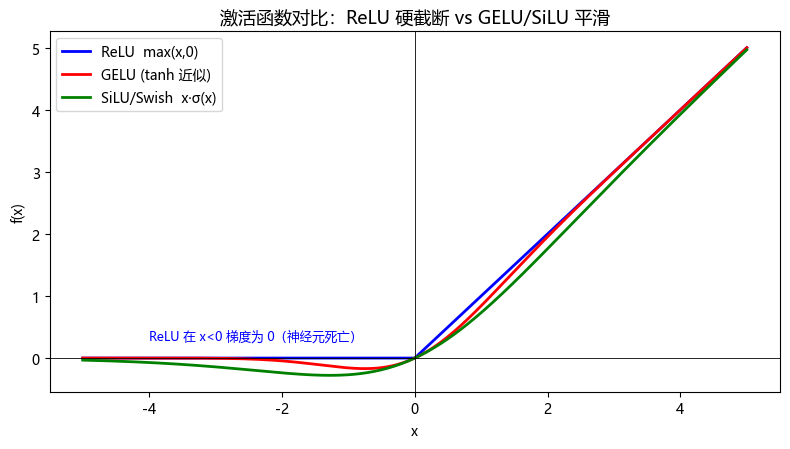

In [11]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

xs = np.linspace(-5, 5, 400)
relu = np.maximum(xs, 0)
a = math.sqrt(2.0 / math.pi) * (xs + 0.044715 * xs ** 3)
gelu = 0.5 * xs * (1 + np.tanh(a))
silu = xs * (1 / (1 + np.exp(-xs)))

fig, ax = plt.subplots(figsize=(8, 4.6))
ax.plot(xs, relu, 'b-', lw=2, label='ReLU  max(x,0)')
ax.plot(xs, gelu, 'r-', lw=2, label='GELU (tanh 近似)')
ax.plot(xs, silu, 'g-', lw=2, label='SiLU/Swish  x·σ(x)')
ax.axhline(0, color='k', lw=0.6); ax.axvline(0, color='k', lw=0.6)
ax.set_xlabel('x'); ax.set_ylabel('f(x)')
ax.set_title('激活函数对比：ReLU 硬截断 vs GELU/SiLU 平滑', fontsize=13)
ax.legend(fontsize=10)
ax.annotate('ReLU 在 x<0 梯度为 0（神经元死亡）', xy=(-4, 0.3), fontsize=9, color='blue')
ax.annotate('GELU/SiLU 负区间仍平滑可导', xy=(-4, -0.7), fontsize=9, color='darkred')
plt.tight_layout(); plt.show()


## SwiGLU 变种（MiniMind/LLaMA 用）

SwiGLU = **Swi**sh 门控 + **GLU**（门控线性单元）：

$$down\Big(SiLU(gate(x))\ \odot\ up(x)\Big)$$

- `gate(x) = xW_g + b_g` 学一个逐元素门控值，经 SiLU 后 ∈ (0, x) 平滑调制
- `up(x) = xW_u + b_u` 提供"内容"
- `down` 把逐元素相乘结果降维回 $d_{model}$

MiniMind 配置：`hidden_act='silu'`、`intermediate_size=2432`（gate/up 各 2432 维）。


In [13]:
def silu(x):
    """SiLU 激活（Swish）：x·sigmoid(x)。"""
    return x * (1.0 / (1.0 + np.exp(-x)))

def swiglu_forward(x, Wg, bg, Wu, bu, Wd, bd):
    """SwiGLU forward：down(SiLU(gate(x)) ⊙ up(x))。
    x: [*, d_model]；Wg,Wu: [d_model, d_ff]；Wd: [d_ff, d_model]。"""
    gate = x @ Wg + bg      # [*, d_ff]：门控值
    up = x @ Wu + bu        # [*, d_ff]：内容
    h = silu(gate) * up     # [*, d_ff]：逐元素门控相乘
    out = h @ Wd + bd       # [*, d_model]
    return out

# ---- torch 参考：同样的 3 个线性层 + F.silu，权重 [out,in] 转置对齐 ----
d_model, d_ff2 = 8, 16
Wg = np.random.randn(d_model, d_ff2) * 0.1
bg = np.random.randn(d_ff2) * 0.1
Wu = np.random.randn(d_model, d_ff2) * 0.1
bu = np.random.randn(d_ff2) * 0.1
Wd = np.random.randn(d_ff2, d_model) * 0.1
bd = np.random.randn(d_model) * 0.1
xs2 = np.random.randn(2, 4, d_model)

out_np = swiglu_forward(xs2, Wg, bg, Wu, bu, Wd, bd)
lin_g = nn.Linear(d_model, d_ff2, dtype=torch.float64); lin_g.weight.data = torch.tensor(Wg.T); lin_g.bias.data = torch.tensor(bg)
lin_u = nn.Linear(d_model, d_ff2, dtype=torch.float64); lin_u.weight.data = torch.tensor(Wu.T); lin_u.bias.data = torch.tensor(bu)
lin_d = nn.Linear(d_ff2, d_model, dtype=torch.float64); lin_d.weight.data = torch.tensor(Wd.T); lin_d.bias.data = torch.tensor(bd)
xt = torch.tensor(xs2, dtype=torch.float64)
out_t = lin_d(F.silu(lin_g(xt)) * lin_u(xt))
e_s = float((out_t.detach().numpy() - out_np).max())
assert np.allclose(out_np, out_t.detach().numpy(), rtol=1e-4, atol=1e-6)
print(f'SwiGLU forward :  max abs err = {e_s:.3e}   ->  PASS')
print('（MiniMind 的 FeedForward 就是这个结构：gate_proj / up_proj / down_proj 三个线性层）')


SwiGLU forward :  max abs err = 2.082e-17   ->  PASS
（MiniMind 的 FeedForward 就是这个结构：gate_proj / up_proj / down_proj 三个线性层）


## SwiGLU 结构图

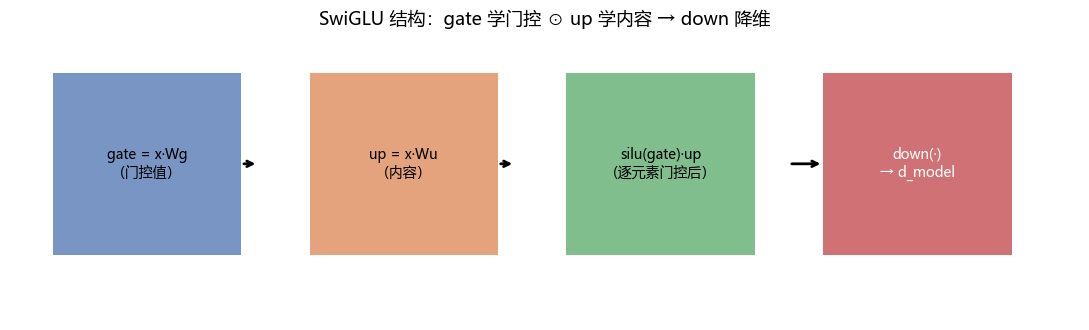

In [15]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

fig, ax = plt.subplots(figsize=(11, 3.4))
# 用色块示意 gate / up / 相乘 三个张量
cols = ['#4C72B0', '#DD8452', '#55A868']
labels = ['gate = x·Wg\n（门控值）', 'up = x·Wu\n（内容）', 'silu(gate)·up\n（逐元素门控后）']
for i, (lbl, col) in enumerate(zip(labels, cols)):
    ax.add_patch(plt.Rectangle((i * 3, 0.5), 2.2, 1.4, facecolor=col, alpha=0.75))
    ax.text(i * 3 + 1.1, 1.2, lbl, ha='center', va='center', fontsize=10)
ax.annotate('', xy=(2.4, 1.2), xytext=(2.2, 1.2), arrowprops=dict(arrowstyle='->', lw=2))
ax.annotate('', xy=(5.4, 1.2), xytext=(5.2, 1.2), arrowprops=dict(arrowstyle='->', lw=2))
ax.annotate('', xy=(9.0, 1.2), xytext=(8.6, 1.2), arrowprops=dict(arrowstyle='->', lw=2))
ax.add_patch(plt.Rectangle((9.0, 0.5), 2.2, 1.4, facecolor='#C44E52', alpha=0.8))
ax.text(10.1, 1.2, 'down(·)\n→ d_model', ha='center', va='center', fontsize=10, color='white')
ax.set_xlim(-0.5, 12); ax.set_ylim(0, 2.2); ax.axis('off')
ax.set_title('SwiGLU 结构：gate 学门控 ⊙ up 学内容 → down 降维', fontsize=13)
plt.tight_layout(); plt.show()


## 总结

- FFN 是逐 token 的"知识存储器"：升维→非线性→降维（$d_{model}\to d_{ff}\to d_{model}$）。
- 激活演进：ReLU（原始 Transformer）→ GELU（GPT-2/BERT）→ SiLU/SwiGLU（LLaMA/MiniMind）：越来越平滑、训练更稳。
- **minLLM 对应位置**：`model/model_minimind.py` 的 `FeedForward`——gate_proj/up_proj/down_proj 三个线性层 + silu，
  `intermediate_size=2432`（768·π/64 向上取整到 64 的倍数）。
- 手搓 backward 与 torch autograd 一致（误差 ~1e-14），梯度推导正确。
